# Training XGBoost (Versi Terbaru)
Notebook ini mengikuti aturan terbaru: drop `id`, pecah `timestamp` menjadi Bulan dan Jam, encoding teks, dan training model XGBoost untuk multi-target (jarak_km, luas_km2, sudut_deg, radius_km).

In [55]:
# Jika xgboost belum terpasang, jalankan baris ini sekali saja.
# %pip install xgboost

import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor

In [56]:
# Konfigurasi utama
USE_ONE_HOT_VOLCANO = True  # Jika False, kolom volcano_filter akan di-drop
TEST_SIZE = 0.1
VAL_SIZE = 0.1  # Proporsi validation dari data train (setelah split test)
RANDOM_STATE = 42

workspace_root = Path.cwd().resolve().parent if Path.cwd().name == 'modeling' else Path.cwd().resolve()
candidate_paths = [
    workspace_root / 'modeling' / 'java-ash-hysplit.csv'
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Dataset tidak ditemukan. Cek path pada candidate_paths.')

# Folder output baru agar hasil preprocessing/split/artifacts mudah dicek
output_root = workspace_root / 'modeling' / 'outputs_xgboost_latest'
preprocess_dir = output_root / 'preprocessed'
split_dir = output_root / 'splits'
artifact_dir = output_root / 'artifacts'

for p in [output_root, preprocess_dir, split_dir, artifact_dir]:
    p.mkdir(parents=True, exist_ok=True)

print('Dataset:', DATA_PATH)
print('Output root:', output_root)

Dataset: D:\Projects\volcanic_ash\modeling\java-ash-hysplit.csv
Output root: D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest


In [57]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]  # Aman dari header dengan spasi tersembunyi

print('Shape awal:', df.shape)
display(df.head(3))
print('Kolom:', df.columns.tolist())

Shape awal: (1707, 16)


,id,timestamp,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km
0,1,2024-06-11 07:34:00 UTC,Merapi,Yellow,-7.54194,110.44194,2968,1000.0,4.7,270.0,50.0,30.0,32.511505,614.390650,303.257335,18.304149
1,2,2024-01-24 08:56:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1000.0,8.0,135.0,51.0,168.0,27.761756,460.792988,37.901873,15.892819
2,3,2023-03-15 03:36:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1200.0,7.1,90.0,65.0,133.0,44.625714,614.214150,265.635506,23.934437


Kolom: ['id', 'timestamp', 'volcano_filter', 'alert_level', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']


In [58]:
# 1) Drop kolom yang tidak informatif
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 2) Feature engineering waktu: timestamp -> Bulan, Jam
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['Bulan'] = df['timestamp'].dt.month
    df['Jam'] = df['timestamp'].dt.hour
    df = df.drop(columns=['timestamp'])
else:
    raise KeyError('Kolom timestamp tidak ditemukan di dataset.')

# 3) Encoding alert_level secara ordinal
# Urutan level bisa disesuaikan jika ada label lain di data
alert_map = {
    'green': 0,
    'yellow': 1,
    'orange': 2,
    'red': 3
}

if 'alert_level' in df.columns:
    alert_clean = df['alert_level'].astype(str).str.strip().str.lower()
    df['alert_level'] = alert_clean.map(alert_map)
    if df['alert_level'].isna().any():
        # Fallback: kategori tak dikenal akan di-encode berurutan
        fallback_codes = pd.Categorical(alert_clean).codes
        df['alert_level'] = df['alert_level'].fillna(pd.Series(fallback_codes, index=df.index))
else:
    raise KeyError('Kolom alert_level tidak ditemukan di dataset.')

# Simpan dataset hasil preprocessing agar bisa dicek manual
preprocessed_path = preprocess_dir / 'dataset_preprocessed.csv'
df.to_csv(preprocessed_path, index=False)

print('Shape setelah preprocessing awal:', df.shape)
print('Dataset preprocessing tersimpan di:', preprocessed_path)
display(df.head(3))

Shape setelah preprocessing awal: (1707, 16)
Dataset preprocessing tersimpan di: D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\preprocessed\dataset_preprocessed.csv


,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km,Bulan,Jam
0,Merapi,1,-7.54194,110.44194,2968,1000.0,4.7,270.0,50.0,30.0,32.511505,614.390650,303.257335,18.304149,6,7
1,Merapi,2,-7.54194,110.44194,2968,1000.0,8.0,135.0,51.0,168.0,27.761756,460.792988,37.901873,15.892819,1,8
2,Merapi,2,-7.54194,110.44194,2968,1200.0,7.1,90.0,65.0,133.0,44.625714,614.214150,265.635506,23.934437,3,3


In [59]:
# Definisi target sesuai requirement
target_cols = ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
missing_targets = [c for c in target_cols if c not in df.columns]
if missing_targets:
    raise KeyError(f'Target tidak ditemukan: {missing_targets}')

y = df[target_cols].copy()
X = df.drop(columns=target_cols).copy()

# Strategi untuk volcano_filter
if not USE_ONE_HOT_VOLCANO and 'volcano_filter' in X.columns:
    X = X.drop(columns=['volcano_filter'])

print('Fitur akhir:', X.columns.tolist())
print('Target akhir:', y.columns.tolist())
print('Shape X:', X.shape, '| Shape y:', y.shape)

Fitur akhir: ['volcano_filter', 'alert_level', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'Bulan', 'Jam']
Target akhir: ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
Shape X: (1707, 12) | Shape y: (1707, 4)


In [60]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

# Simpan split ke CSV (fitur + target) agar mudah diinspeksi
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
val_df = pd.concat([X_val.reset_index(drop=True), y_val.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

train_csv_path = split_dir / 'train.csv'
val_csv_path = split_dir / 'val.csv'
test_csv_path = split_dir / 'test.csv'

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print('Train split tersimpan di:', train_csv_path)
print('Val split tersimpan di  :', val_csv_path)
print('Test split tersimpan di :', test_csv_path)
print('Shape train/val/test:', X_train.shape, X_val.shape, X_test.shape)

categorical_cols = [c for c in X_train.columns if X_train[c].dtype == 'object']
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_cols
        )
    ],
    remainder='drop'
)

xgb_base = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', MultiOutputRegressor(xgb_base))
    ]
)

model.fit(X_train, y_train)
print('Training selesai.')

Train split tersimpan di:

 D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\splits\train.csv
Val split tersimpan di  : D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\splits\val.csv
Test split tersimpan di : D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\splits\test.csv
Shape train/val/test: (1382, 12) (154, 12) (171, 12)
Training selesai.


In [61]:
y_pred = model.predict(X_test)
pred_df = pd.DataFrame(y_pred, columns=target_cols, index=y_test.index)

rows = []
for col in target_cols:
    rmse = root_mean_squared_error(y_test[col], pred_df[col])
    r2 = r2_score(y_test[col], pred_df[col])
    rows.append({'target': col, 'rmse': rmse, 'r2': r2})

metrics_df = pd.DataFrame(rows).sort_values('target')
display(metrics_df)

rmse_global = root_mean_squared_error(y_test, pred_df)
r2_global = r2_score(y_test, pred_df, multioutput='uniform_average')
print(f'Global RMSE: {rmse_global:.4f}')
print(f'Global R2  : {r2_global:.4f}')

,target,rmse,r2
0,jarak_km,9.559886,0.852591
1,luas_km2,204.626145,0.803225
3,radius_km,5.748499,0.829310
2,sudut_deg,73.590896,0.537301


Global RMSE: 73.3814
Global R2  : 0.7556


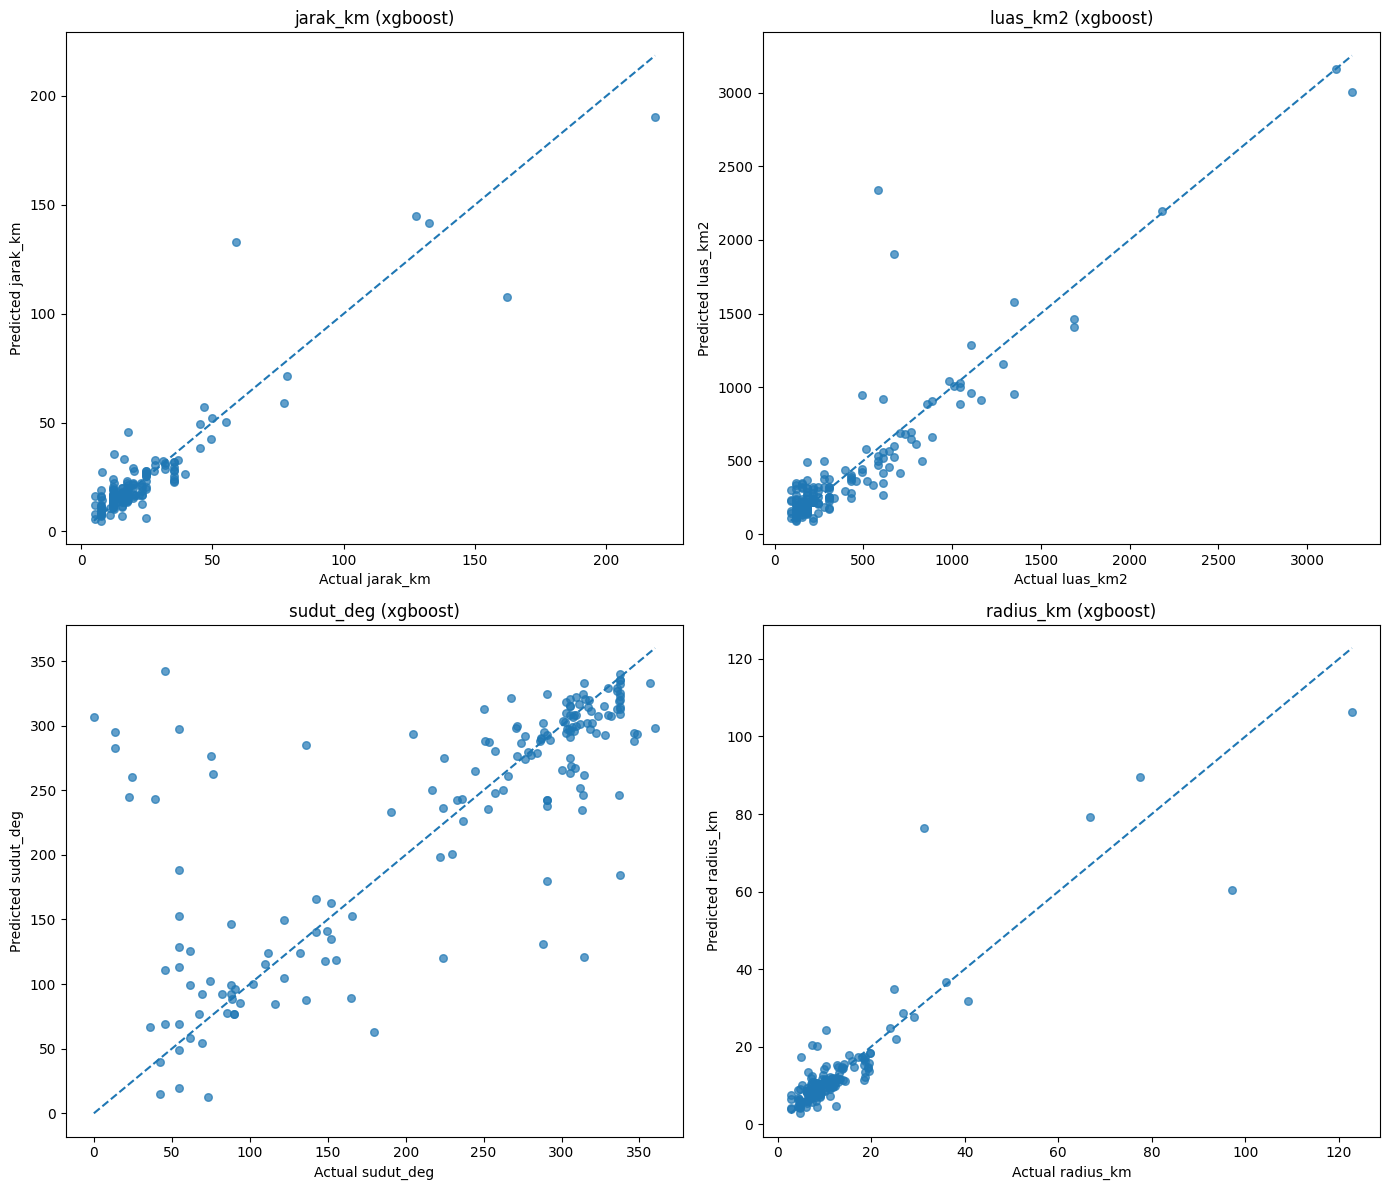

In [62]:
# Plot evaluasi: Actual vs Predicted untuk tiap target
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(target_cols):
    ax = axes[i]
    actual = y_test[col].values
    pred = pred_df[col].values

    ax.scatter(actual, pred, alpha=0.7, s=30)

    min_v = min(actual.min(), pred.min())
    max_v = max(actual.max(), pred.max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle='--', linewidth=1.5)

    ax.set_title(f'{col} (xgboost)')
    ax.set_xlabel(f'Actual {col}')
    ax.set_ylabel(f'Predicted {col}')

plt.tight_layout()
plt.show()

In [63]:
# Contoh prediksi 1 baris data uji
sample_X = X_test.head(1)
sample_pred = model.predict(sample_X)

print('Input sample:')
display(sample_X)

print('Prediksi target:')
display(pd.DataFrame(sample_pred, columns=target_cols))

Input sample:


,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,Bulan,Jam
567,Semeru,2,-8.10805,112.92,3676,500.0,3.3,225.0,22.0,115.0,10,23


Prediksi target:


,jarak_km,luas_km2,sudut_deg,radius_km
0,22.503378,364.469666,302.199951,12.275596


In [64]:
# Simpan model dan artifacts
import joblib

model_path = artifact_dir / 'xgboost_multioutput_pipeline.joblib'
metrics_path = artifact_dir / 'metrics_test.csv'
config_path = artifact_dir / 'training_config.json'

joblib.dump(model, model_path)
metrics_df.to_csv(metrics_path, index=False)

training_config = {
    'data_path': str(DATA_PATH),
    'use_one_hot_volcano': USE_ONE_HOT_VOLCANO,
    'test_size': TEST_SIZE,
    'val_size': VAL_SIZE,
    'random_state': RANDOM_STATE,
    'target_cols': target_cols,
    'feature_cols': X.columns.tolist(),
    'split_files': {
        'train': str(train_csv_path),
        'val': str(val_csv_path),
        'test': str(test_csv_path)
    },
    'global_metrics_test': {
        'rmse': float(rmse_global),
        'r2': float(r2_global)
    }
}

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(training_config, f, ensure_ascii=False, indent=2)

print('Model tersimpan di   :', model_path)
print('Metrics tersimpan di :', metrics_path)
print('Config tersimpan di  :', config_path)
print('Semua artifacts ada di folder:', artifact_dir)

Model tersimpan di   : D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\artifacts\xgboost_multioutput_pipeline.joblib
Metrics tersimpan di : D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\artifacts\metrics_test.csv
Config tersimpan di  : D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\artifacts\training_config.json
Semua artifacts ada di folder: D:\Projects\volcanic_ash\modeling\outputs_xgboost_latest\artifacts
